# Case II

This notebook reproduces the Case II plots seen in Sections 4.2 and B.1 of the paper.

The notebook contains:

1. A diffusion-width sweep over $W_D \in \{2, 4, 8\}$ for the three non-constant diffusion families.
2. Training-diagnostics and diffusion-MSE comparisons across $ES \in \{2000, 3000, 5000\}$.
3. Grid-based diffusion-profile comparisons for the same sweep, grouped by diffusion family and $ES$.

*It produces plots for Fig. 8 and Fig. A2 in the paper.*


In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import sympy as sp

PROJECT_ROOT = next(
    path
    for path in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (path / "Training").is_dir()
)
project_root_str = str(PROJECT_ROOT)
if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

from Training.JN.notebook_helpers.notebook_data import build_catalog, load_data_object, load_original_data
from Training.JN.notebook_helpers.notebook_config import (
    BCbool,
    BNdataLossFuncLabel,
    D_one_param_bool,
    binn_batch_size,
    binn_lr,
    binn_model_num,
    binn_rel_save_thresh,
    binn_rel_update_thresh,
    binnDevice,
    binnGenerateIndicesLabel,
    binnVF,
)
from Training.JN.notebook_helpers.notebook_models import (
    active_constraint_settings,
    build_model_catalog,
    build_model_path,
    filter_model_catalog,
    load_requested_models,
    summarize_requested_models,
)
from Training.JN.notebook_helpers.notebook_setup import bootstrap_notebook, register_notebook_pickle_globals

paths = bootstrap_notebook(PROJECT_ROOT)
PROJECT_ROOT = paths.project_root
JN_ROOT = paths.notebook_root

register_notebook_pickle_globals()

from paper_helpers import (
    scale_function_by_percent_error,
    plot_diff_mse_lst,
    plot_eval_D_multi_gray_gridLayout,
    plot_final_loss_lst_colLayout,
    plot_initial_condition_1d,
    plot_total_run_times_lst_colLayout,
)


## 1. Load the Case II data

We first recover the shared reaction-diffusion grids used throughout Case II, then load the three data objects that differ only through the prescribed diffusion law. As in Case I, this verifies that the expected data objects exist on disk before any model analysis begins. The spatial and temporal grids follow [Lagergren et al. (2020)](https://doi.org/10.1371/journal.pcbi.1008462)

MSE between u and u_clean: 0.0
ABS between u and u_clean [cells]: 0.0
ABS (%) between u and u_clean: 0.0


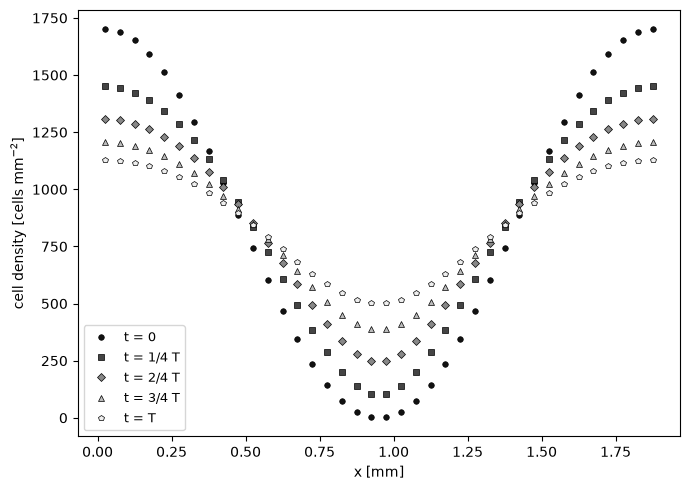

In [2]:
DATA_ROOT = paths.data_root

data_orig_obj_FKPP = load_original_data(DATA_ROOT)
x = data_orig_obj_FKPP.x
t = data_orig_obj_FKPP.t
K = 1  # Densities are normalized so the effective carrying capacity is 1.

data_df = build_catalog(DATA_ROOT, target_filename="data_obj.npy")

CASE2_SHARED_DATA_CONFIG = {
    "dataX1num": len(x),
    "dataX2num": 1,
    "dataTnum": len(t),
    "dataK": K,
    "dataICLabel": "cos",
    "dataGrowLabel": "zero",
    "dataGamma": 0,
    "dataNoisePercent": 0,
    "dataNoiseSeed": 0,
}

diff_labels = ["linear", "quadratic", "exp"]
case2_data_config_by_diff = {
    diff_label: CASE2_SHARED_DATA_CONFIG | {"dataDiffLabel": diff_label}
    for diff_label in diff_labels
}
data_obj_by_diff = {}
for diff_label in diff_labels:
    data_obj_by_diff[diff_label], _ = load_data_object(
        case2_data_config_by_diff[diff_label],
        DATA_ROOT,
        data_df=data_df,
    )

plot_initial_condition_1d(data_obj_by_diff[diff_labels[0]])


## 2. Build the Case II model catalogue & form helper functions for model loading and plotting


### 2.1. Catalogue trained model

Next we catalogue all saved BINN checkpoints under `Training/binn`, filter them to the fixed Case II assumptions, and preview the subset that supports the diffusion-width sweep below.

The varying dimensions in this notebook are `dataDiffLabel`, `binnES`, `binnDsize`, and `binnTVsplitSeed`; everything else is held fixed for Case II.


In [3]:
BINN_ROOT = paths.binn_root
binn_df = build_model_catalog(BINN_ROOT)

# =================================== 1D specific settings ===================================
numPDEsamples = 1000

# ====================== Diffusion only, no growth specific settings ==========================
allConstraints = True
constraintTuple = (True, True, False, False)
constraintWeights = {
    "D_bound_weight": 0,
    "D_mono_weight": 1e1,
    "G_bound_weight": 0,
    "G_mono_weight": 1e1,
}
constraintBounds = {
    "D_bound": (0, 0.1),
    "G_bound": (-0.02 / (1 / 24), 0.1 / (1 / 24)),
}
W_G = None
# =============================================================================================

CASE2_SWEEP_CONFIG = {
    "WD_values": [2, 4, 8],
    "Wu": 64,
    "ES_values": [2000, 3000, 5000],
    "split_seeds": [0, 1, 2],
}


def build_case2_fixed_filters(diff_label):
    filters = case2_data_config_by_diff[diff_label] | {
        "binnVF": binnVF,
        "binnGenerateIndicesLabel": binnGenerateIndicesLabel,
        "binnUsize": CASE2_SWEEP_CONFIG["Wu"],
        "binnGsize": W_G,
        "DoneParamBool": D_one_param_bool,
        "binnDevice": binnDevice,
        "allConstraints": allConstraints,
        "BCbool": BCbool,
        "numPDEsamples": numPDEsamples,
        "binnLR": binn_lr,
        "binnBatchSize": binn_batch_size,
        "binnRelUpdateThresh": binn_rel_update_thresh,
        "binnRelSaveThresh": binn_rel_save_thresh,
        "BNdataLossFuncLabel": BNdataLossFuncLabel,
    }
    if allConstraints:
        filters |= active_constraint_settings(
            constraintTuple,
            constraintWeights,
            constraintBounds,
        )
    return filters


case2_catalog_by_diff = {}
for diff_label in diff_labels:
    catalog = filter_model_catalog(
        binn_df,
        build_case2_fixed_filters(diff_label),
        empty_message=f"No BINN models were found for the fixed Case II assumptions with diffusion label {diff_label!r}.",
    )
    case2_catalog_by_diff[diff_label] = catalog.sort_values(
        ["binnES", "binnDsize", "binnTVsplitSeed"]
    ).reset_index(drop=True)

CATALOG_COLUMNS = ["binnES", "binnDsize", "binnTVsplitSeed", "full_path"]
case2_catalog_by_diff[diff_labels[0]][CATALOG_COLUMNS]


,binnES,binnDsize,binnTVsplitSeed,full_path
0,2000,2,0,/Users/willa954/Desktop/Git-personal/Hyperpara...
1,2000,2,1,/Users/willa954/Desktop/Git-personal/Hyperpara...
2,2000,2,2,/Users/willa954/Desktop/Git-personal/Hyperpara...
3,2000,4,0,/Users/willa954/Desktop/Git-personal/Hyperpara...
4,2000,4,1,/Users/willa954/Desktop/Git-personal/Hyperpara...
5,2000,4,2,/Users/willa954/Desktop/Git-personal/Hyperpara...
6,2000,8,0,/Users/willa954/Desktop/Git-personal/Hyperpara...
7,2000,8,1,/Users/willa954/Desktop/Git-personal/Hyperpara...
8,2000,8,2,/Users/willa954/Desktop/Git-personal/Hyperpara...
9,3000,2,0,/Users/willa954/Desktop/Git-personal/Hyperpara...


### 2.2. Helper functions for loading trained models


In [4]:
def build_case2_model_path(diff_label, W_D, binnSplitSeed, binn_ES):
    return build_model_path(
        BINN_ROOT,
        build_case2_fixed_filters(diff_label),
        {
            "binnTVsplitSeed": binnSplitSeed,
            "binnDsize": W_D,
            "binnES": binn_ES,
        },
        model_df=case2_catalog_by_diff[diff_label],
        model_label=binn_model_num,
    )


def build_requested_case2_models(diff_label, es_values, wd_values, split_seeds):
    return [
        {
            "binnES": binn_ES,
            "binnDsize": W_D,
            "binnTVsplitSeed": binnSplitSeed,
            "path": build_case2_model_path(diff_label, W_D, binnSplitSeed, binn_ES),
        }
        for binn_ES in es_values
        for W_D in wd_values
        for binnSplitSeed in split_seeds
    ]


def summarize_case2_model_availability(diff_label, es_values, wd_values, split_seeds):
    requested_models = build_requested_case2_models(diff_label, es_values, wd_values, split_seeds)
    print(f"Diffusion = {diff_label}")
    return summarize_requested_models(
        requested_models,
        label_keys=["binnES", "binnDsize", "binnTVsplitSeed"],
    )


def load_case2_models(diff_labels, es_values, wd_values, split_seeds):
    models_by_diff = {}
    for diff_label in diff_labels:
        summarize_case2_model_availability(diff_label, es_values, wd_values, split_seeds)
        requested_models = build_requested_case2_models(diff_label, es_values, wd_values, split_seeds)
        models_by_diff[diff_label] = load_requested_models(
            requested_models,
            device=binnDevice,
            group_keys=("binnES", "binnDsize", "binnTVsplitSeed"),
        )
    return models_by_diff


binn_models_by_diff = load_case2_models(
    diff_labels=diff_labels,
    es_values=CASE2_SWEEP_CONFIG["ES_values"],
    wd_values=CASE2_SWEEP_CONFIG["WD_values"],
    split_seeds=CASE2_SWEEP_CONFIG["split_seeds"],
)

probe_model = binn_models_by_diff[diff_labels[0]][CASE2_SWEEP_CONFIG["ES_values"][0]][CASE2_SWEEP_CONFIG["WD_values"][1]][CASE2_SWEEP_CONFIG["split_seeds"][0]]
total_p = sum(p.numel() for p in probe_model.model.diffusion.parameters())
print(f"Number of parameters for W_D = {CASE2_SWEEP_CONFIG['WD_values'][1]} is {total_p}\n")


Diffusion = linear
Requested model combinations: 27
Already trained model files found: 27
Missing model files: 0
Diffusion = quadratic
Requested model combinations: 27
Already trained model files found: 27
Missing model files: 0
Diffusion = exp
Requested model combinations: 27
Already trained model files found: 27
Missing model files: 0
Number of parameters for W_D = 4 is 53



### 2.3 Shared plotting style

These settings are reused across the diagnostics, diffusion-MSE summaries, and profile plots for the Case II sweep.


In [5]:
BLUE_COLORS = ["#0033A0", "#1E90FF", "#6699CC", "#A4C8E1", "#D6EAF8"]
D_COLORS = ["#8B2500", "#FF7F0E", "#FDB863", "#FDD9B5", "#FFF1E0"]
linestyles = ["-"] * 5
MARKER_STYLES = ["o"] * 5
HATCH_PATTERNS = ("///", "...", "xxx")
LEGEND_SIZE = 18
AXIS_FONTSIZES = {
    "xaxis": 20,
    "xtick_labels": 20,
    "yaxis": 20,
    "ytick_labels": 20,
}

CASE2_PLOT_CONFIG = {
    "linear": {
        "xmax": 4e4,
        "beta_list": [0.5, 1, 2],
        "mse_ylim": [1e-8, 5e-5],
        "profile_Dnum": 2,
        "profile_legend_pos": (0.15, 0.65),
        "profile_ylim": [0.01, 0.08],
        "profile_fill": True,
        "training_loss_bbox": (0.077, 1.01),
        "training_loss_ylim": [5e-8, 5e-6],
        "training_loss_ncols": 1,
        "training_time_bbox": (0, 1.02),
        "training_time_ylim": [0.5e3, 1e4],
        "training_time_ncols": 3,
        "mse_bbox": (0.67, 1.02),
        "mse_pe_bbox_offset": (-0.69, 0),
        "mse_pe_ncols": 1,
    },
    "quadratic": {
        "xmax": 4e4,
        "beta_list": [2, 3],
        "mse_ylim": [1e-8, 5e-5],
        "profile_Dnum": 3,
        "profile_legend_pos": (0.88, 0.3),
        "profile_ylim": [0, 0.059],
        "profile_fill": True,
        "training_loss_bbox": (0, 1.02),
        "training_loss_ylim": [5e-8, 7e-6],
        "training_loss_ncols": 1,
        "training_time_bbox": (0, 1.02),
        "training_time_ylim": [0.5e3, 1e4],
        "training_time_ncols": 3,
        "mse_bbox": (0.67, 1.02),
        "mse_pe_bbox_offset": (-0.69, 0),
        "mse_pe_ncols": 2,
    },
    "exp": {
        "xmax": 7e4,
        "beta_list": [2, 3],
        "mse_ylim": [1e-7, 5e-4],
        "profile_Dnum": 4,
        "profile_legend_pos": (0.12, 0.7),
        "profile_ylim": [0, 0.11],
        "profile_fill": False,
        "training_loss_bbox": (0.035, 1.02),
        "training_loss_ylim": [5e-8, 3e-5],
        "training_loss_ncols": 3,
        "training_time_bbox": (0, 1.02),
        "training_time_ylim": [0.5e3, 1e4],
        "training_time_ncols": 3,
        "mse_bbox": (0.67, 1.02),
        "mse_pe_bbox_offset": (-0.69, 0),
        "mse_pe_ncols": 1,
    },
}

diffusion_models = {
    "const": (lambda u, a: np.full_like(u, a), [0.02472]),
    "linear": (lambda u, a, b: a + b * u, [0.015, 0.06]),
    "quadratic": (lambda u, a, b: a + b * u**2, [0.01, 0.044]),
    "exp": (lambda u, a, b, c: a + b * (1 - np.exp(-c * u)), [0.003, 0.095, 2.5]),
}


def plot_params_from_models(models_dict, colors):
    labels = [str(key) for key in models_dict.keys()]
    return {
        key: [colors[i], linestyles[i], MARKER_STYLES[i], labels[i]]
        for i, key in enumerate(models_dict.keys())
    }


def models_by_es_list(diff_label):
    return [binn_models_by_diff[diff_label][ES] for ES in CASE2_SWEEP_CONFIG["ES_values"]]


def make_diffusion_func(diff_label):
    diff_func, theta_D = diffusion_models[diff_label]

    def diffusion_func(u):
        return diff_func(u, *theta_D)

    return diffusion_func


def symbolic_diffusion(diff_label):
    u = sp.Symbol("u")
    if diff_label == "const":
        return diffusion_models[diff_label][1][0]
    if diff_label == "linear":
        a, b = diffusion_models[diff_label][1]
        return a + b * u
    if diff_label == "quadratic":
        a, b = diffusion_models[diff_label][1]
        return a + b * u**2
    if diff_label == "exp":
        a, b, c = diffusion_models[diff_label][1]
        return a + b * (1 - sp.exp(-c * u))
    raise KeyError(f"Unknown diffusion label: {diff_label}")


def reference_mses(diff_label, beta_list):
    diffusion_func = make_diffusion_func(diff_label)
    return [scale_function_by_percent_error(diffusion_func, beta=beta)[1] for beta in beta_list]


## 3. Sweep A: vary $W_D$ across diffusion families and $ES$ values at fixed $W_u = 64$

This section reproduces the main Case II sweep. For each diffusion family, we compare the diffusion-network widths $W_D \in \{2, 4, 8\}$ across the three epoch budgets while holding the density-network width fixed.


In [6]:
name_intro_binn_col = JN_ROOT / "pngs" / "1D" / "case2" / "fig8_LHS"
name_intro_diff = JN_ROOT / "pngs" / "1D" / "case2" / "figA2"

os.makedirs(name_intro_binn_col, exist_ok=True)
os.makedirs(name_intro_diff, exist_ok=True)


All x-axis labels found (ordered): ['2', '4', '8']
saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case2/fig8_LHS/linear_plot_a_1


/Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/paper_helpers/plotting_final_loss.py:407: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax1.grid(bool(grid), axis="y", which="both", linestyle="-", linewidth=0.5, alpha=grid_alpha)


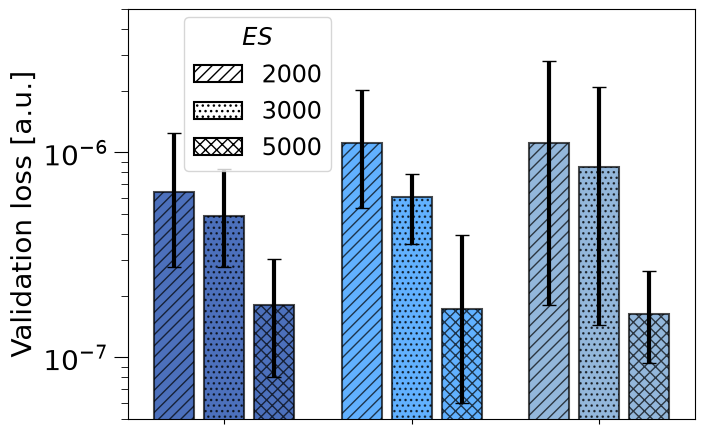

All x-axis labels found (ordered): ['2', '4', '8']
Mean runtime increases between corresponding models across groups:
  2000 -> 3000
    2: 1011.264s -> 1287.098s (delta +275.834s)
    4: 976.971s -> 1805.375s (delta +828.404s)
    8: 886.291s -> 1185.688s (delta +299.397s)
    mean delta: +467.878s
  3000 -> 5000
    2: 1287.098s -> 2910.778s (delta +1623.679s)
    4: 1805.375s -> 4327.451s (delta +2522.077s)
    8: 1185.688s -> 3264.160s (delta +2078.472s)
    mean delta: +2074.743s
saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case2/fig8_LHS/linear_plot_a_2


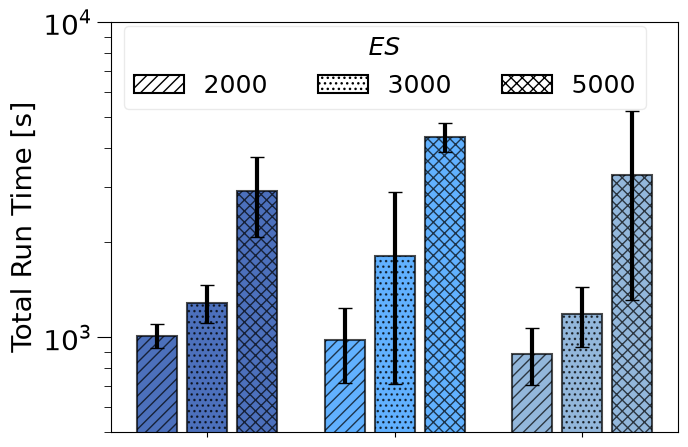

All x-axis labels found (ordered): ['2', '4', '8']
saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case2/fig8_LHS/quadratic_plot_a_1


/Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/paper_helpers/plotting_final_loss.py:407: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax1.grid(bool(grid), axis="y", which="both", linestyle="-", linewidth=0.5, alpha=grid_alpha)


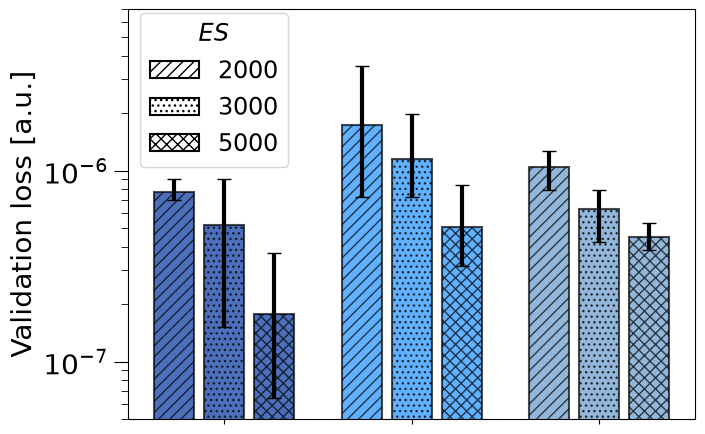

All x-axis labels found (ordered): ['2', '4', '8']
Mean runtime increases between corresponding models across groups:
  2000 -> 3000
    2: 1232.763s -> 1968.997s (delta +736.234s)
    4: 959.208s -> 1420.077s (delta +460.869s)
    8: 1082.959s -> 1515.579s (delta +432.620s)
    mean delta: +543.241s
  3000 -> 5000
    2: 1968.997s -> 3754.325s (delta +1785.328s)
    4: 1420.077s -> 3006.422s (delta +1586.345s)
    8: 1515.579s -> 2336.666s (delta +821.087s)
    mean delta: +1397.587s
saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case2/fig8_LHS/quadratic_plot_a_2


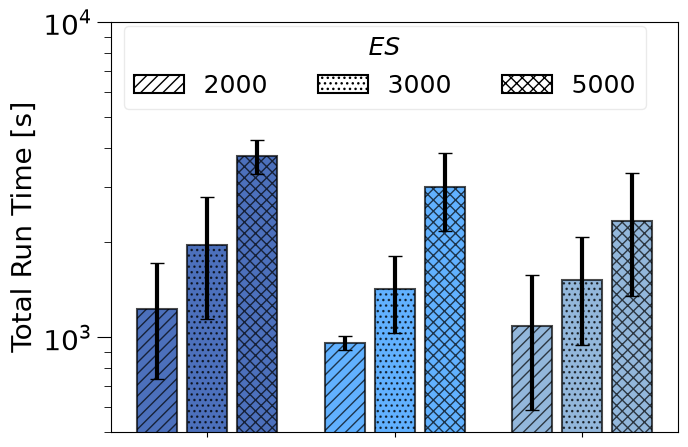

All x-axis labels found (ordered): ['2', '4', '8']
saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case2/fig8_LHS/exp_plot_a_1


/Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/paper_helpers/plotting_final_loss.py:407: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax1.grid(bool(grid), axis="y", which="both", linestyle="-", linewidth=0.5, alpha=grid_alpha)


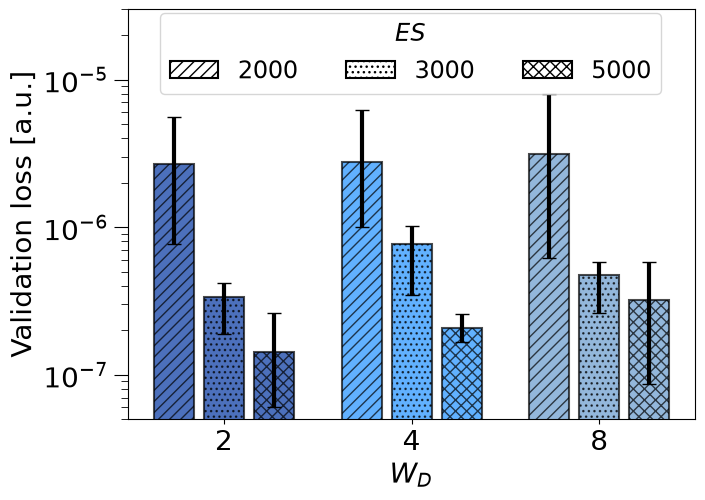

All x-axis labels found (ordered): ['2', '4', '8']
Mean runtime increases between corresponding models across groups:
  2000 -> 3000
    2: 1268.996s -> 2887.796s (delta +1618.801s)
    4: 919.292s -> 1868.833s (delta +949.541s)
    8: 1204.177s -> 2584.225s (delta +1380.048s)
    mean delta: +1316.130s
  3000 -> 5000
    2: 2887.796s -> 4567.925s (delta +1680.128s)
    4: 1868.833s -> 3980.147s (delta +2111.314s)
    8: 2584.225s -> 4109.672s (delta +1525.447s)
    mean delta: +1772.297s
saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case2/fig8_LHS/exp_plot_a_2


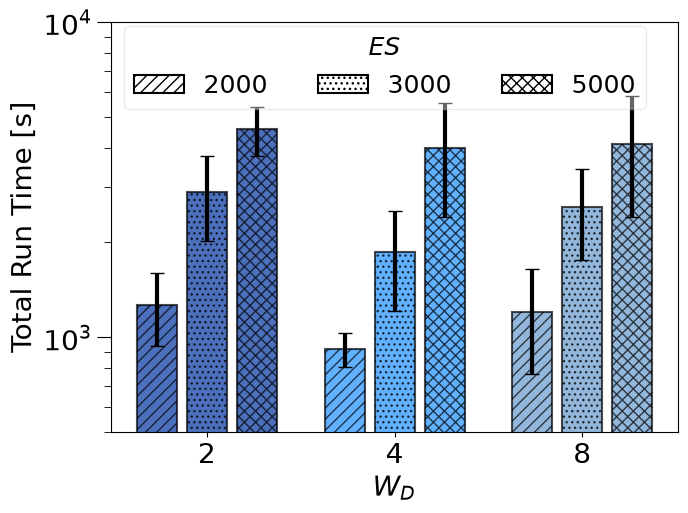

In [7]:
# Produces the training-loss and total-runtime panels on the left-hand side of Fig. 8.
for row_idx, diff_label in enumerate(diff_labels):
    cfg = CASE2_PLOT_CONFIG[diff_label]
    models_for_plot = models_by_es_list(diff_label)
    models_chosen_ES = binn_models_by_diff[diff_label][CASE2_SWEEP_CONFIG["ES_values"][0]]
    plot_params = plot_params_from_models(models_chosen_ES, BLUE_COLORS)

    show_xlabel = row_idx == len(diff_labels) - 1
    show_xtick_labels = row_idx == len(diff_labels) - 1

    plot_final_loss_lst_colLayout(
        models_for_plot,
        plot_params=plot_params,
        label_list=[f"{ES}" for ES in CASE2_SWEEP_CONFIG["ES_values"]],
        name=str(name_intro_binn_col / f"{diff_label}_plot_a_1"),
        bbox_to_anchor=cfg["training_loss_bbox"],
        legend_ncols=cfg["training_loss_ncols"],
        y_label="Validation loss [a.u.]",
        legend_size=17.5,
        axis_fontsizes=AXIS_FONTSIZES,
        figsize=(7, 5),
        hatch_patterns=HATCH_PATTERNS,
        x_label=r"$W_D$",
        show_xlabel=show_xlabel,
        show_xtick_labels=show_xtick_labels,
        legend_title=r"$ES$",
        ylim=cfg["training_loss_ylim"]
    )

    plot_total_run_times_lst_colLayout(
        models_dics_list=models_for_plot,
        plot_params=plot_params,
        label_list=[f"{ES}" for ES in CASE2_SWEEP_CONFIG["ES_values"]],
        legend_fontsize=LEGEND_SIZE,
        name=str(name_intro_binn_col / f"{diff_label}_plot_a_2"),
        hatch_patterns=HATCH_PATTERNS,
        x_label=r"$W_D$",
        axis_fontsizes=AXIS_FONTSIZES,
        legend_pos=cfg["training_time_bbox"],
        y_lim=cfg["training_time_ylim"],
        legend_ncols=cfg["training_time_ncols"],
        show_xlabel=show_xlabel,
        show_xtick_labels=show_xtick_labels,
        legend_title=r"$ES$"
    )

All x-axis labels found (ordered): ['2', '4', '8']
saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case2/figA2/plot_a.png


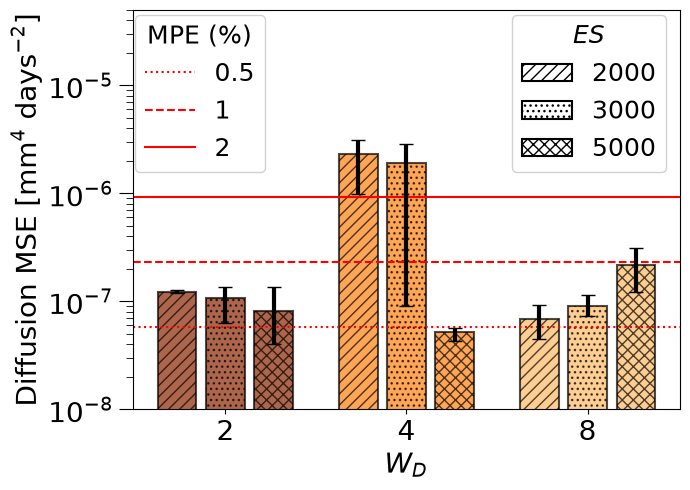

All x-axis labels found (ordered): ['2', '4', '8']
saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case2/figA2/plot_b.png


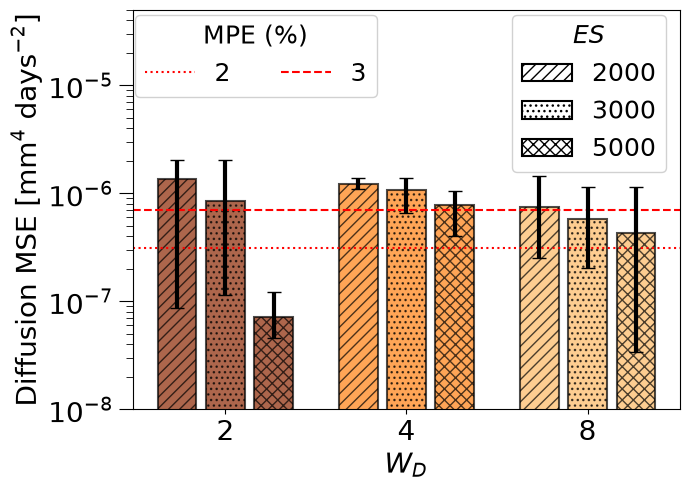

All x-axis labels found (ordered): ['2', '4', '8']
saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case2/figA2/plot_c.png


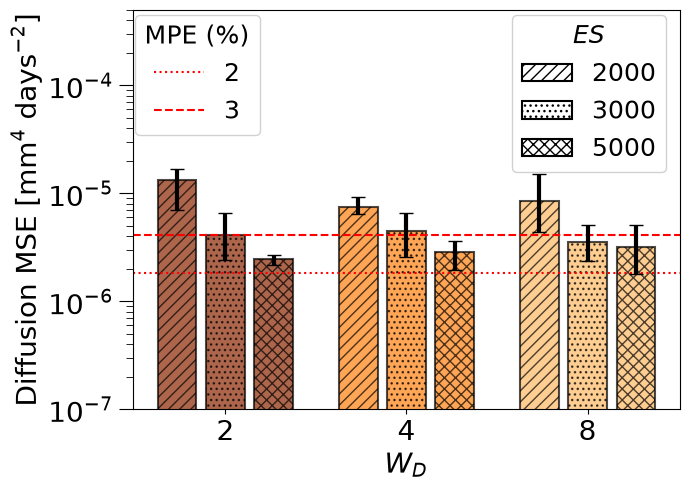

In [8]:
# Diffusion-MSE summaries for Fig. A2, varying W_D within each diffusion family.
for idx, diff_label in enumerate(diff_labels):
    cfg = CASE2_PLOT_CONFIG[diff_label]
    models_for_plot = models_by_es_list(diff_label)
    models_chosen_ES = binn_models_by_diff[diff_label][CASE2_SWEEP_CONFIG["ES_values"][0]]
    plot_params_D = plot_params_from_models(models_chosen_ES, D_COLORS)

    beta_list = cfg["beta_list"]
    mses = reference_mses(diff_label, beta_list)

    plot_diff_mse_lst(
        models_for_plot,
        plot_params=plot_params_D,
        label_list=[f"{ES}" for ES in CASE2_SWEEP_CONFIG["ES_values"]],
        name=str(name_intro_diff / f"plot_{chr(ord('a') + idx)}.png"),
        figsize=(7, 5),
        colors=D_COLORS,
        pe_label_list=[f"{beta}" for beta in beta_list],
        pe_values=mses,
        pe_linestyles=(":", "--", "-", "-."),
        pe_legend_ncols=cfg["mse_pe_ncols"],
        hatch_patterns=HATCH_PATTERNS,
        x_label=r"$W_D$",
        pe_legend_title="MPE (%)",
        restrict_to_central_90=False,
        bbox_to_anchor=cfg["mse_bbox"],
        pe_bbox_to_anchor_offset=cfg["mse_pe_bbox_offset"],
        legend_size=LEGEND_SIZE,
        axis_fontsizes=AXIS_FONTSIZES,
        legend_title=r"$ES$",
        ylim=cfg["mse_ylim"],
    )


## 4. Sweep B configuration: grid-based diffusion-profile comparisons across $W_D$ and $ES$

The final panels revisit the same sweep in function space. Each row fixes the diffusion family, each column fixes the epoch budget, and the plotted curves compare the three diffusion-network widths.


In [9]:
name_intro_diff_grid = JN_ROOT / "pngs" / "1D" / "case2" / "fig8_RHS"
os.makedirs(name_intro_diff_grid, exist_ok=True)


saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case2/fig8_RHS/linear_plot_0.png


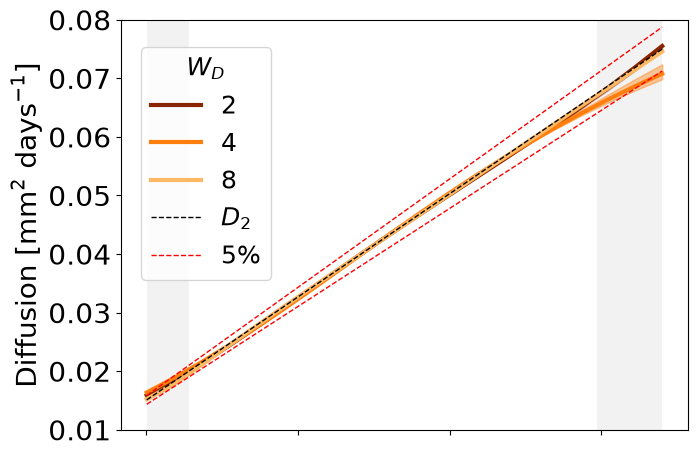

saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case2/fig8_RHS/linear_plot_1.png


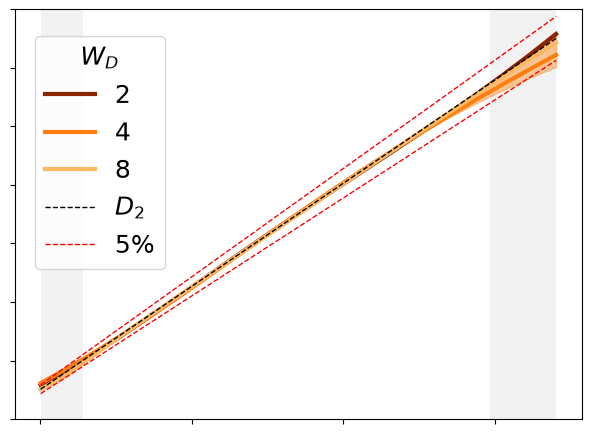

saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case2/fig8_RHS/linear_plot_2.png


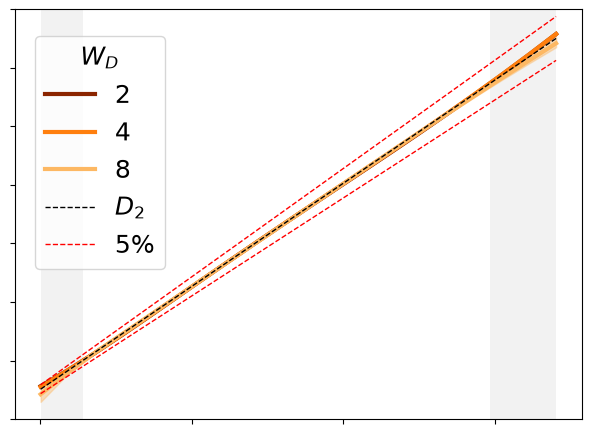

saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case2/fig8_RHS/quadratic_plot_0.png


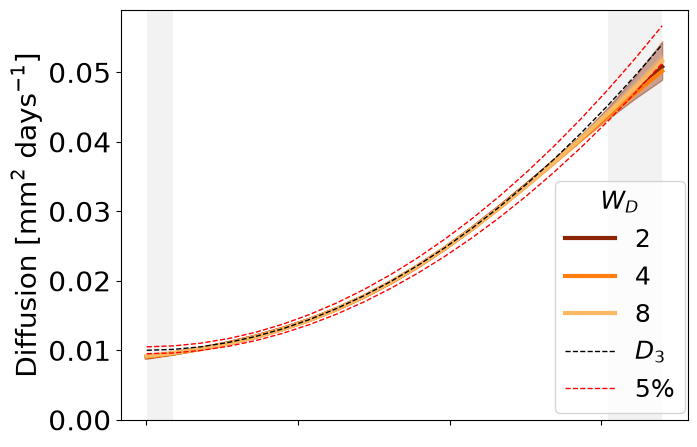

saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case2/fig8_RHS/quadratic_plot_1.png


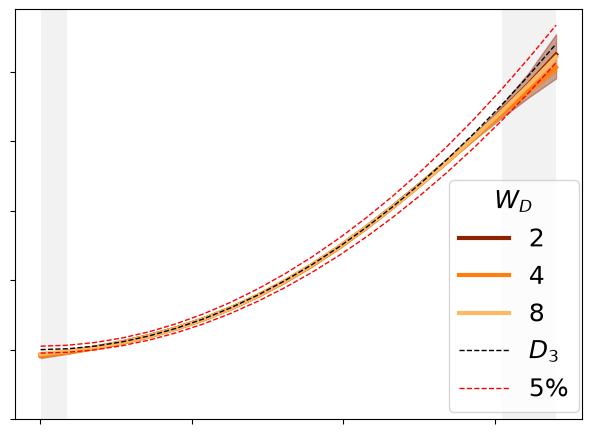

saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case2/fig8_RHS/quadratic_plot_2.png


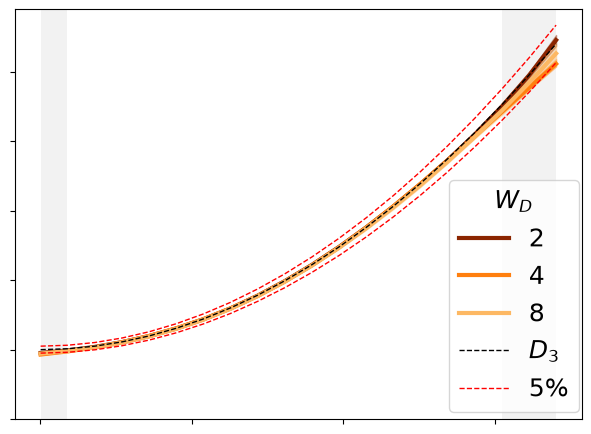

saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case2/fig8_RHS/exp_plot_0.png


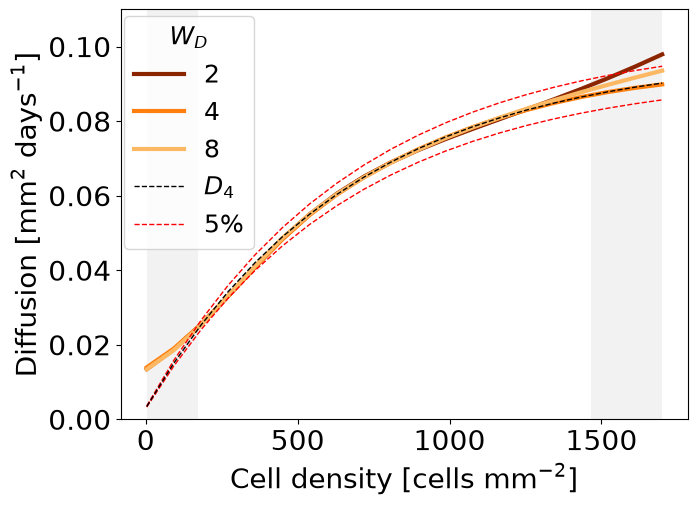

saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case2/fig8_RHS/exp_plot_1.png


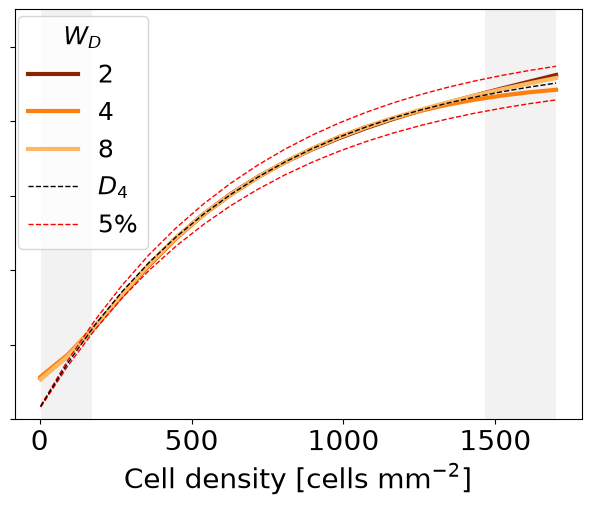

saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case2/fig8_RHS/exp_plot_2.png


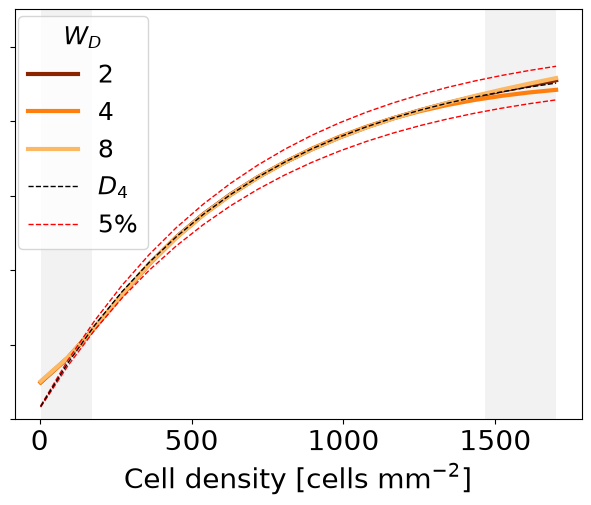

In [10]:
# Produces the diffusion-profile grid on the right-hand side of Fig. 8.
for row_idx, diff_label in enumerate(diff_labels):
    cfg = CASE2_PLOT_CONFIG[diff_label]
    for col_idx, binn_ES in enumerate(CASE2_SWEEP_CONFIG["ES_values"]):
        models_chosen_ES = binn_models_by_diff[diff_label][binn_ES]
        model_groups = {f"{W_D}": models for W_D, models in models_chosen_ES.items()}
        labels = list(model_groups.keys())

        plot_eval_D_multi_gray_gridLayout(
            model_groups,
            data_obj_by_diff[diff_label],
            [symbolic_diffusion(diff_label)],
            D_COLORS,
            labels,
            Dnum=cfg["profile_Dnum"],
            device=binnDevice,
            num_bins=50,
            K=1700,
            name=str(name_intro_diff_grid / f"{diff_label}_plot_{col_idx}.png"),
            fill=cfg["profile_fill"],
            linestyles=linestyles,
            legend_title=r"$W_D$",
            legend_fontsize=LEGEND_SIZE,
            axis_fontsizes=AXIS_FONTSIZES,
            figsize=(7, 5),
            errs=[5, 5],
            legend_pos=cfg["profile_legend_pos"],
            legend_ncols=1,
            y_lim=cfg["profile_ylim"],
            show_xlabel=(row_idx == len(diff_labels) - 1),
            show_ylabel=(col_idx == 0),
            show_xtick_labels=(row_idx == len(diff_labels) - 1),
            show_ytick_labels=(col_idx == 0),
        )


## References

J. H. Lagergren et al. "Biologically-informed neural networks guide mechanistic modeling from sparse experimental data". In: *PLoS Comput Biol* 16.12 (2020), e1008462. DOI: [10.1371/journal.pcbi.1008462](https://doi.org/10.1371/journal.pcbi.1008462).
